In [1]:
%pip install pandas numpy scikit-learn joblib matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import joblib

In [3]:
import sys
print(sys.executable)

c:\Users\saqib\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [ ]:
# 1. CSV files load
bulb_df = pd.read_csv(r'C:\Users\saqib\OneDrive\Desktop\wemo_mlops_pipeline\data\bulb.csv')
bulb_fan_df = pd.read_csv(r'C:\Users\saqib\OneDrive\Desktop\wemo_mlops_pipeline\data\bulbandfan.csv')
charger_df = pd.read_csv(r'C:\Users\saqib\OneDrive\Desktop\wemo_mlops_pipeline\data\mobilecharger.csv')

# 2. Labels assign 
bulb_df['appliance'] = 'Bulb'
bulb_fan_df['appliance'] = 'Bulb + Fan'
charger_df['appliance'] = 'Mobile Charger'

# 3. Master Dataset 
df = pd.concat([bulb_df, bulb_fan_df, charger_df], ignore_index=True)

# 4. Data Cleaning
df = df[df['power_W'] > 0.5]

print("Data Loaded and Cleaned Successfully!")
print(f"Total valid samples: {len(df)}")
print("\nAppliance Distribution:")
print(df['appliance'].value_counts())

Data Loaded and Cleaned Successfully!
Total valid samples: 205

Appliance Distribution:
appliance
Mobile Charger    79
Bulb + Fan        69
Bulb              57
Name: count, dtype: int64


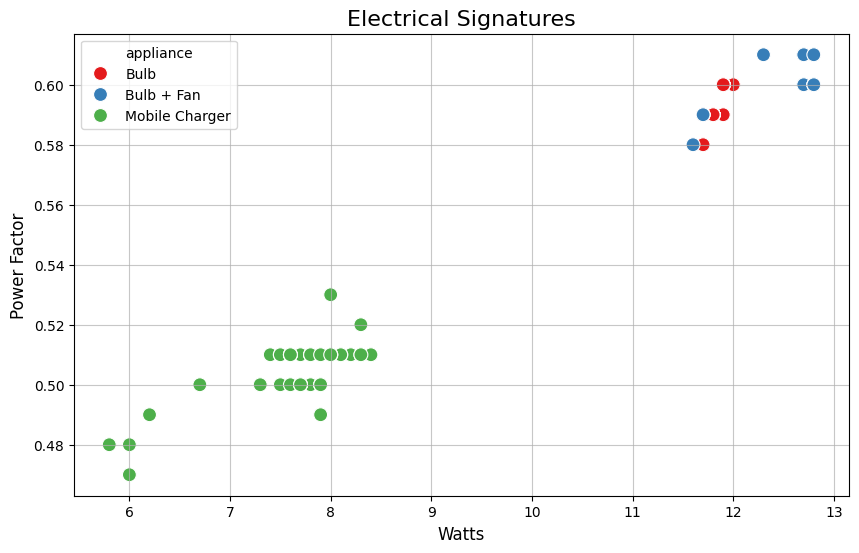

In [ ]:
# Data graph
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='power_W', y='power_factor', hue='appliance', palette='Set1', s=100)
plt.title('Electrical Signatures', fontsize=16)
plt.xlabel('Watts', fontsize=12)
plt.ylabel('Power Factor', fontsize=12)
plt.grid(True, alpha=0.7)
plt.show()

In [ ]:
# Training the ml model
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

X = df[['power_W', 'power_factor']]
y = df['appliance']

# splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN model 
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Accuracy check 
accuracy = knn.score(X_test_scaled, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 100.00%


In [ ]:
# for new and unknown load
def classify_load(power, pf):
    new_point = scaler.transform([[power, pf]])
    distances, _ = knn.kneighbors(new_point)
    
    # if the point is too far from known data, flaging it as unknown
    if distances[0][0] > 1.5:  
        return " UNKNOWN LOAD DETECTED"
    else:
        return knn.predict(new_point)[0]

# Testing the function with new loads
print("Test Bulb 11.8W:", classify_load(11.8, 0.60)) 
print("Test Laptop 65.0W:", classify_load(65.0, 0.95))

Test Bulb 11.8W: Bulb
Test Laptop 65.0W:  UNKNOWN LOAD DETECTED


c:\Users\saqib\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\saqib\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [12]:
# Model save 
import joblib

joblib.dump(knn, 'wemo_knn_model.pkl')
joblib.dump(scaler, 'wemo_scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
